In [ ]:
#-------------------------------
# INSTALLING UNARCHIVE-DO MODULE
#-------------------------------


!apt-get install unrar


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
#----------------------
# UNARCHIVING NPPAD.rar
#----------------------

!unrar x /content/Operation_csv_data.rar /content/Operation_csv_data_extracted/



UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Operation_csv_data.rar

Creating    /content/Operation_csv_data_extracted                     OK
Creating    /content/Operation_csv_data_extracted/Operation_csv_data  OK
Creating    /content/Operation_csv_data_extracted/Operation_csv_data/ATWS  OK
Extracting  /content/Operation_csv_data_extracted/Operation_csv_data/ATWS/1.csv       0%  OK 
Creating    /content/Operation_csv_data_extracted/Operation_csv_data/FLB  OK
Extracting  /content/Operation_csv_data_extracted/Operation_csv_data/FLB/1.csv       0%  OK 
Extracting  /content/Operation_csv_data_extracted/Operation_csv_data/FLB/10.csv       0%  OK 
Extracting  /content/Operation_csv_data_extracted/Operation_csv_data/FLB/100.csv       0%  OK 
Extracting  /content/Operation_csv_data_extracted/Operation_csv_data/FLB/11.csv       0%  OK 
Extracting  /content/Operation_csv_data_extracted/Operation

In [ ]:
#-----------------------------------------------------
# IMORTING CSV FILES AND PERFORMING REQUIRED OPERTIONS
#-----------------------------------------------------

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

data_dir = '/content/Operation_csv_data_extracted/Operation_csv_data'
sequence_length = 50

all_sequences = []
all_labels = []
label_map = {}
label_idx = 0
reference_columns = None

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        label_map[label_idx] = folder
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            if not file.lower().endswith('.csv'):
                continue
            try:
                df = pd.read_csv(file_path)
                if reference_columns is None:
                    reference_columns = df.columns.tolist()
                    if 'TIME' in reference_columns:
                        reference_columns.remove('TIME')
                df = df.drop(columns=['TIME'], errors='ignore')

                # Align columns
                df = df.reindex(columns=reference_columns)
                df = df.fillna(0)

                scaler = StandardScaler()
                df_scaled = scaler.fit_transform(df)

                for i in range(0, len(df_scaled) - sequence_length + 1, sequence_length):
                    seq = df_scaled[i:i + sequence_length]
                    all_sequences.append(seq)
                    all_labels.append(label_idx)
            except Exception as e:
                print(f"Failed to process {file_path}: {e}")
        label_idx += 1

all_sequences = np.stack(all_sequences)
all_labels = np.array(all_labels)

print(" Total sequences:", all_sequences.shape)
print(" Label map:", label_map)


 Total sequences: (9386, 50, 96)
 Label map: {0: 'SLBIC', 1: 'FLB', 2: 'SP', 3: 'SGBTR', 4: 'LLB', 5: 'TT', 6: 'RI', 7: 'SGATR', 8: 'LACP', 9: 'LOCAC', 10: 'RW', 11: 'MD', 12: 'ATWS', 13: 'LOCA', 14: 'SLBOC', 15: 'LR', 16: 'Normal', 17: 'LOF'}


In [ ]:
#----------------------------
# DEFINING MODEL ARCHITECTURE
#----------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

class TransformerModel(nn.Module):
    def __init__(self, input_size, num_classes, num_heads=4, num_layers=3, hidden_dim=64, dropout=0.1):
        super(TransformerModel, self).__init__()

        self.encoder_layer = nn.TransformerEncoderLayer(d_model=input_size, nhead=num_heads, dim_feedforward=hidden_dim, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_size, num_classes)

    def forward(self, x):
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        return x

# Model parameters
input_size = 96
num_classes = 18

# Initialize the model
model = TransformerModel(input_size=input_size, num_classes=num_classes)
print(model)

TransformerModel(
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
    )
    (linear1): Linear(in_features=96, out_features=64, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=64, out_features=96, bias=True)
    (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
#--------------------
# SPILITTING THE DATA
#--------------------

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    all_sequences, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)


In [ ]:
#---------
# TRAINING
#---------

import torch.optim as optim

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs},  Loss: {avg_loss:.4f}")


Epoch 1/20, Loss: 1.2659
Epoch 2/20, Loss: 0.3895
Epoch 3/20, Loss: 0.2606
Epoch 4/20, Loss: 0.2322
Epoch 5/20, Loss: 0.2008
Epoch 6/20, Loss: 0.1690
Epoch 7/20, Loss: 0.1740
Epoch 8/20, Loss: 0.1523
Epoch 9/20, Loss: 0.1423
Epoch 10/20, Loss: 0.1333
Epoch 11/20, Loss: 0.1391
Epoch 12/20, Loss: 0.1422
Epoch 13/20, Loss: 0.1200
Epoch 14/20, Loss: 0.1064
Epoch 15/20, Loss: 0.1020
Epoch 16/20, Loss: 0.1014
Epoch 17/20, Loss: 0.1141
Epoch 18/20, Loss: 0.1023
Epoch 19/20, Loss: 0.0936
Epoch 20/20, Loss: 0.0987


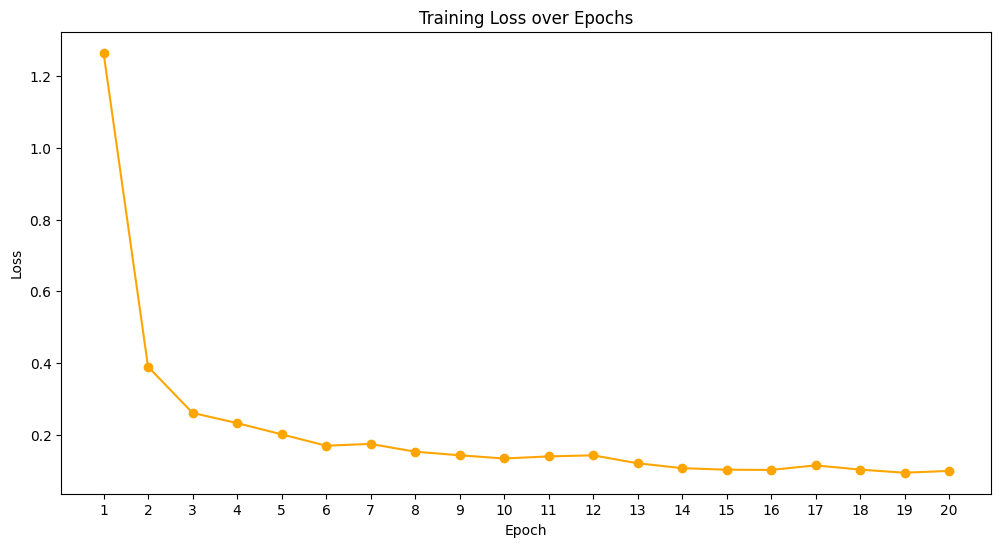

In [ ]:
#--------------------
# PLOTTING LOSS CURVE
#--------------------

import matplotlib.pyplot as plt

losses = [
    1.2659, 0.3895, 0.2606, 0.2322, 0.2008,
    0.1690, 0.1740, 0.1523, 0.1423, 0.1333,
    0.1391, 0.1422, 0.1200, 0.1064, 0.1020,
    0.1014, 0.1141, 0.1023, 0.0936, 0.0987
]

epochs = range(1, len(losses) + 1)

# Plotting the loss curve
plt.figure(figsize=(12, 6))
plt.plot(epochs, losses, marker='o', color='orange', linestyle='-')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.xticks(epochs)
plt.show()


In [ ]:
#-----------
# EVALUATION
#-----------

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9425


In [ ]:
#-----------------------------------
# SAVE THE TRAINED TRANSFORMER MODEL
#-----------------------------------

import joblib
torch.save(model.state_dict(), 'transformer_model.pth')

In [ ]:
#---------------
# SAVE THE TRAINED SCALAR
#---------------

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
#--------------------
# PREDICTING SEQUENCE
#--------------------

def predict_sequence(sequence_np):
    sequence_tensor = torch.tensor(sequence_np, dtype=torch.float32).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(sequence_tensor)
        predicted_class = torch.argmax(output, dim=1).item()
    return predicted_class, output.softmax(dim=1).cpu().numpy()

In [ ]:
#----------------------------------------------
# INFERENCING ON LIVE-INCOMING READINGS (.csvs)
#----------------------------------------------

import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# === Define your Transformer model ===
class TransformerModel(nn.Module):
    def __init__(self, input_size, num_classes, num_heads=4, num_layers=3, hidden_dim=64, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=input_size, nhead=num_heads, dim_feedforward=hidden_dim, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_size, num_classes)

    def forward(self, x):
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        return x

# === Load saved model ===
input_size = 96
num_classes = 18  # You have 18 classes (0-17)
model = TransformerModel(input_size, num_classes)
model.load_state_dict(torch.load('transformer_model.pth', map_location='cpu'))
model.eval()

# === Load scaler (IMPORTANT: must match training time scaler) ===
scaler = StandardScaler()  # or the loaded scaler as joblib.load('scaler.pkl')
# Ideally: fit scaler on your original training data and save it to disk, then load here.
# For this example, we assume you fit it live on incoming data.
# To make it robust, fit scaler once and pickle it.

# === Label map ===
label_map = {
    0: 'ATWS', 1: 'FLB', 2: 'LACP', 3: 'LLB', 4: 'LOCA', 5: 'LOCAC', 6: 'LOF',
    7: 'LR', 8: 'MD', 9: 'Normal', 10: 'RI', 11: 'RW', 12: 'SGATR', 13: 'SGBTR',
    14: 'SLBIC', 15: 'SLBOC', 16: 'SP', 17: 'TT'
}

# === Function to run inference ===
def run_inference_on_csv(csv_path, sequence_length=50):
    df = pd.read_csv(csv_path)
    if 'TIME' in df.columns:
        df = df.drop(columns=['TIME'], errors='ignore')

    df = df.fillna(0)
    df_scaled = scaler.fit_transform(df)  # NOTE: replace with scaler.transform(df) if you saved scaler

    sequences = []
    for i in range(0, len(df_scaled) - sequence_length + 1, sequence_length):
        seq = df_scaled[i:i + sequence_length]
        sequences.append(seq)

    if not sequences:
        print(f"[WARN] Not enough data in {csv_path} for a full sequence.")
        return

    sequences = np.stack(sequences)
    sequences = torch.tensor(sequences, dtype=torch.float32)

    with torch.no_grad():
        outputs = model(sequences)
        preds = torch.argmax(outputs, dim=1)

    for idx, pred in enumerate(preds):
        label = label_map[pred.item()]
        if label != 'Normal':
            print(f"[ALERT] Sequence {idx} predicted anomaly: {label}")
        else:
            print(f"[INFO] Sequence {idx} predicted as Normal")

# === Simulate real-time monitoring loop ===
def monitor_directory(live_dir, check_interval=5):
    seen_files = set()
    print("[INFO] Starting real-time monitoring...")
    while True:
        files = [f for f in os.listdir(live_dir) if f.endswith('.csv')]
        new_files = set(files) - seen_files
        for file in new_files:
            file_path = os.path.join(live_dir, file)
            print(f"[INFO] Processing new file: {file}")
            run_inference_on_csv(file_path)
            seen_files.add(file)
        time.sleep(check_interval)

# === Example usage ===
# live_data_dir = '/path/to/live/csv/files'
# monitor_directory(live_data_dir)
